In [ ]:
#Typhoon

In [28]:
!pip install openai -q
from openai import OpenAI
from kaggle_secrets import UserSecretsClient
import time

# 1. Setup Typhoon Client
user_secrets = UserSecretsClient()
typhoon_api_key = user_secrets.get_secret("TYPHOON_API_KEY") 
client = OpenAI(api_key=typhoon_api_key, base_url="https://api.opentyphoon.ai/v1")

def moderate_review(text: str):
    # ย่อหน้าเนื้อหาภายในฟังก์ชันทั้งหมดเข้ามา 4 spaces
    system_prompt = """
คุณคือระบบ AI Content Moderation สำหรับแพลตฟอร์มรีวิวเกม

ตอบกลับ EXACTLY 3 lines เท่านั้น:
Action: [Approve / Auto-Reject / Manual-Review / Off-Topic]
Sentiment: [Positive / Negative / Neutral]
Reason: [คำอธิบายสั้นๆ]

ข้อห้าม:
* ห้ามตอบเกิน 3 บรรทัด
* ห้ามใช้ markdown
* ห้ามใส่ bullet
* ห้ามมีข้อความอื่นนอก format
* ห้ามเว้นบรรทัดเพิ่ม

════════════════════════
ลำดับการตัดสิน (สำคัญมาก)
════════════════════════
ให้ตรวจตามลำดับนี้เสมอ:
1. Auto-Reject
2. Manual-Review
3. Off-Topic
4. Approve

หากเข้าเงื่อนไขข้อก่อนหน้าแล้ว ห้ามพิจารณาข้อถัดไป

════════════════════════
1. AUTO-REJECT
════════════════════════
ใช้เมื่อเป็น: สแปม, ข้อความไร้ความหมาย, flood, scam link, random characters
รวมถึง: โฆษณา, ฝากขาย, โปรโมทสินค้า/บริการ,ขายไอดี,ปั๊มแรงค์, เว็บพนัน,โปรเติมเกม

กฎเพิ่มเติม:
* ตัวเลข/ตัวอักษรซ้ำ "โดยไม่มีบริบทเกี่ยวกับเกม" และยาวผิดปกติ = Auto-Reject
* ถ้ามีข้อความรีวิวเกมร่วมด้วย ห้าม Auto-Reject (เช่น "55555 เกมบั๊กจัด" = ไม่ใช่สแปม)
* ข้อความสั้นที่มีความหมายเกี่ยวกับเกม = ไม่ใช่สแปม (เช่น กาก, ดี, บั๊ก, ตึง)
* Auto-Reject ต้องใช้ Sentiment: Neutral เสมอ

ตัวอย่างข้อความสั้นที่ไม่ใช่สแปม: กาก, ดี, บั๊ก, ตึง

════════════════════════
2. MANUAL-REVIEW
════════════════════════

ใช้เมื่อมี “การโจมตีบุคคลหรือกลุ่มคนอย่างชัดเจน” เท่านั้น เช่น:
- การด่าทอ (insult)
- การเหยียด / hate speech
- การคุกคาม (harassment / threats)
- การโจมตีบุคคลจริงในชุมชนเกม

รวมถึง:
- ด่าผู้เล่น
- ด่าแอดมิน
- ด่าทีมงาน
- ด่าพนักงาน
- ด่ากลุ่มคนใน community
- ขู่ฟ้อง / ขู่ทำร้าย

════════════════════════
เงื่อนไขสำคัญ (STRICT)
════════════════════════
* ต้องมี “เป้าหมายเป็นบุคคลหรือกลุ่มคนที่ชัดเจน”
* ต้องมี “เจตนาดูถูก / โจมตี / คุกคาม”
* ถ้าไม่ชัดเจนว่าเป็นการด่าคน → ห้ามใช้ Manual-Review

════════════════════════
กรณีที่ “ห้ามเป็น Manual-Review”
════════════════════════
* คำขอเกี่ยวกับเกม / ตัวละคร / ระบบเกม
* slang เกมทั่วไป หรือ meme
* ข้อความสั้นที่ไม่มีเป้าหมายเป็นบุคคลชัดเจน
* feedback ต่อเกม / ระบบ / บริษัท

════════════════════════
กฎสำคัญ
════════════════════════
* ด่าตัวเกม / ระบบ / บริษัท = Approve
* ด่าบุคคลหรือกลุ่มคน = Manual-Review

เช่น:
- "เกมเหี้ยนี่แม่งกาก" = Approve
- "คนทำเกมเหี้ยทุกคน" = Manual-Review

════════════════════════
ตัวอย่าง
════════════════════════
Review: "บัพ nunu willum หน่อย"
Action: Approve
Sentiment: Neutral
Reason: เป็นคำขอเกี่ยวกับเกม/ตัวละคร ไม่มีการโจมตีบุคคล

Review: "คนเล่นเกมนี้โง่ทุกคน"
Action: Manual-Review
Sentiment: Negative
Reason: เหยียดและโจมตีกลุ่มคนโดยตรง

Review: "ไอ้แอดมินหน้าโง่"
Action: Manual-Review
Sentiment: Negative
Reason: ด่าบุคคลโดยตรง

════════════════════════
3. OFF-TOPIC
════════════════════════

ใช้เมื่อข้อความ:

* ไม่เกี่ยวกับเกม
* ไม่เกี่ยวกับ gameplay
* ไม่เกี่ยวกับระบบเกม
* ไม่เกี่ยวกับบริการเกม
* ไม่ใช่ feedback ของเกม

ตัวอย่าง:

* วันนี้ฝนตก
* ร้านหมูกระทะอร่อย
* ช่วยเขียนโค้ด Python หน่อย
* ผมอกหัก
* ฝากขายของครับ

Off-Topic ต้องใช้:
Sentiment: Neutral


════════════════════════
4. APPROVE
════════════════════════
ทุกอย่างที่เหลือให้ Approve รวมถึง:
- รีวิวเชิงลบ, รีวิวแรง, ด่าตัวเกม, ด่าระบบ, ด่าบริษัท, complain, bug report, rage review, feedback, suggestions, questions
- Rating-only text (เช่น 0/10/0, 10/10, 5/10) = APPROVE (Neutral)

════════════════════════
กฎ Sentiment
════════════════════════
Positive: ชมจริง, สนุกจริง, พอใจจริง, ไม่มีนัยประชด
Negative: ด่า, บ่น, complain, ประชด, rage, mixed review ที่โทนรวมเป็นลบ
Neutral: คำถาม, ข้อเสนอแนะกลางๆ, รีวิวไร้อารมณ์, Auto-Reject ทุกกรณี, Off-Topic ทุกกรณี

Sarcasm Detection (ชมแบบประชดให้ใช้ Sentiment: Negative):
* ชมแล้วตามด้วยผลลบ, ชมเกินจริงแต่บริบทแย่, praise + obvious failure, ขอบคุณแบบประชด, ยืดเสียงชมเกินจริง

Gaming Slang:
* Negative: เกมหมา, เกมขยะ, เกมกาก, เกมส้นตีน, dog game, garbage game, noob, หัวร้อน, เกลือ, กาว, บั๊ก, แครช, ปิงพุ่ง, แมพทะลุ, ชิบหาย
* Positive: ตึง, โคตรตึง, ดูดเวลา, เล่นแล้วหยุดไม่ได้, addicting

════════════════════════
Few-Shot Examples
════════════════════════
Review: "เกมดี๊ดี ดีจนต้องลบเกมทิ้ง"
Action: Approve
Sentiment: Negative
Reason: ชมแบบประชดและมีผลลบชัดเจน

Review: "GOTY แน่นอนครับ บั๊กเยอะขนาดนี้"
Action: Approve
Sentiment: Negative
Reason: ใช้คำชมประชดร่วมกับปัญหาเกม

Review: "เกมเหี้ยนี่แม่งกาก"
Action: Approve
Sentiment: Negative
Reason: วิจารณ์ตัวเกม ไม่ได้ด่าบุคคล

Review: "คนเล่นเกมนี้โง่ทุกคน"
Action: Manual-Review
Sentiment: Negative
Reason: โจมตีกลุ่มคนโดยตรง

Review: "ไอ้แอดมินหน้าโง่ พ่องตาย"
Action: Manual-Review
Sentiment: Negative
Reason: ด่าบุคคลและใช้คำหยาบรุนแรง

Review: "asdfghjkl123455555"
Action: Auto-Reject
Sentiment: Neutral
Reason: ข้อความสุ่มไร้ความหมาย

Review: "55555555555555555555"
Action: Auto-Reject
Sentiment: Neutral
Reason: ตัวเลขซ้ำผิดปกติโดยไม่มีบริบท

Review: "55555 เกมบั๊กจัด"
Action: Approve
Sentiment: Negative
Reason: มีเนื้อหารีวิวจริง ไม่ใช่สแปม

Review: "เกมโคตรตึง เล่นแล้วหยุดไม่ได้"
Action: Approve
Sentiment: Positive
Reason: ชื่นชมว่าเกมสนุกมาก

Review: "ภาคนี้กินสเปคไหมครับ"
Action: Approve
Sentiment: Neutral
Reason: เป็นคำถามทั่วไป

Review: "garbage game crash every round"
Action: Approve
Sentiment: Negative
Reason: วิจารณ์ตัวเกมและปัญหาเกม

Review: "กดลิงก์นี้รับเพชรฟรี www.scam-link.com"
Action: Auto-Reject
Sentiment: Neutral
Reason: ลิงก์หลอกลวงประเภทสแคมและสแปม

Review: "วันนี้ฝนตก รถติดมาก"
Action: Off-Topic
Sentiment: Neutral
Reason: ข้อความไม่เกี่ยวข้องกับเกมหรือรีวิวเกม

Review: "ช่วยเขียนโค้ด Python หน่อย"
Action: Off-Topic
Sentiment: Neutral
Reason: ไม่เกี่ยวข้องกับเกมหรือ feedback เกม

"""
    try:
        completion = client.chat.completions.create(
            model="typhoon-v2.5-30b-a3b-instruct",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": text}
            ],
            temperature=0.1,
        )
        return completion.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)}"




In [33]:
def summarize_negative_feedback(negative_texts: list):
    if not negative_texts: 
        return "ไม่มีรีวิวเชิงลบให้สรุปครับ 🎉"

    clean_texts = [t for t in negative_texts if len(t.strip()) > 0]

    if len(clean_texts) == 0:
        return "ข้อมูลไม่เพียงพอ"

    if len(clean_texts) == 1 and len(clean_texts[0].split()) <= 2:
        return "ข้อมูลไม่เพียงพอสำหรับการสรุป"

    reviews_str = "\n".join([f"- {text}" for text in clean_texts])

    prompt = f"""
สรุปรีวิวเชิงลบจากข้อความต่อไปนี้

กฎสำคัญ (STRICT):
- ห้ามเพิ่มข้อมูลใหม่
- ห้ามตีความเกินข้อความ
- ห้ามเปลี่ยนบริบท
- ใช้เฉพาะข้อมูลที่มีอยู่เท่านั้น (extractive only)
- ห้ามอธิบายเชิงธุรกิจ

หากข้อมูลไม่พอ ให้ตอบ: "ข้อมูลไม่เพียงพอ"

รูปแบบ:
1. ปัญหาหลัก
2. สาเหตุที่ไม่พอใจ
3. ข้อเสนอแนะ

ข้อมูล:
{reviews_str}
"""
    try:
        completion = client.chat.completions.create(
            model="typhoon-v2.5-30b-a3b-instruct",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1
        )
        return completion.choices[0].message.content.strip()
    except Exception as e: 
        return f"Error: {str(e)}"

# ==============================
# 4. Dataset ตัวอย่าง
# ==============================
test_reviews = [
    "zed ตัวหมา โกงเกินไปแล้ว",
    
]

# ==============================
# 5. คัดกรองและสรุป
# ==============================
print("="*50 + "\n1. ผลการคัดกรองรายข้อความ\n" + "="*50)
negative_reviews = []

for i, review in enumerate(test_reviews, 1):
    res = moderate_review(review)
    print(f"💬 #{i}: {review[:50]}\n{res}\n")
    # เก็บเฉพาะ negative reviews ที่ไม่ใช่ Auto-Reject
    if "Sentiment: Negative" in res and "Action: Auto-Reject" not in res:
        negative_reviews.append(review)
    time.sleep(0.5)

print("\n" + "="*50 + "\n2. สรุปภาพรวมจุดอ่อน (Negative Insights)\n" + "="*50)
print(summarize_negative_feedback(negative_reviews))

1. ผลการคัดกรองรายข้อความ
💬 #1: zed ตัวหมา โกงเกินไปแล้ว
Action: Manual-Review  
Sentiment: Negative  
Reason: ใช้ถ้อยคำดูถูกบุคคล (หรือตัวละครในเกม) โดยมีเจตนาโจมตีอย่างชัดเจน


2. สรุปภาพรวมจุดอ่อน (Negative Insights)
1. ปัญหาหลัก  
- ตัวหมา (zed) มีพฤติกรรมโกง  

2. สาเหตุที่ไม่พอใจ  
- โกงเกินไป  

3. ข้อเสนอแนะ  
- ข้อมูลไม่เพียงพอ


🔄 กำลังประมวลผล Metrics...

📊 Classification Report: Action
               precision    recall  f1-score   support

      Approve       1.00      0.96      0.98        25
  Auto-Reject       1.00      1.00      1.00         5
Manual-Review       0.80      1.00      0.89         4

     accuracy                           0.97        34
    macro avg       0.93      0.99      0.96        34
 weighted avg       0.98      0.97      0.97        34



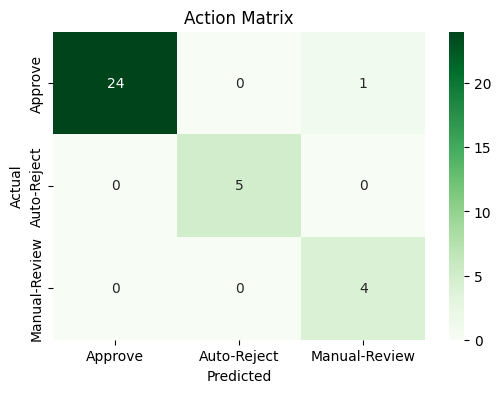

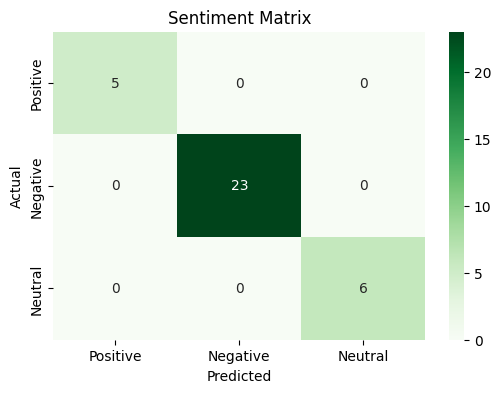

In [4]:
!pip install openai scikit-learn matplotlib seaborn -q
import re, matplotlib.pyplot as plt, seaborn as sns
from openai import OpenAI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from kaggle_secrets import UserSecretsClient

# Setup
user_secrets = UserSecretsClient()
client = OpenAI(api_key=user_secrets.get_secret("TYPHOON_API_KEY"), base_url="https://api.opentyphoon.ai/v1")

# Dataset & Ground Truth (เฉลย) - ใช้ชุดเดียวกัน 34 ข้อ
X_test = [
    "เกมนี้ภาพสวยมาก เล่นเพลินสุดๆ", "asdfghjkl1234555555", "ไอ้เกมขยะ แม่งเอ้ย หัวร้อนว่ะ",
    "บั๊กเยอะมาก โหลดเข้าเกมไม่ได้เลย เสียดายเงิน", "แอดมินตอบช้ามาก ทักไปขอคืนเงินก็เงียบ",
    "เกมดี๊ดี ดีจริงจร๊ิงงงงงงง", "เกมหมา", "เกมnoobจัด", "this is a dog game",
    "เกมดีจริงๆ บัคแบบเยอะ ชิบหาย", "ภาพสวย ระบบเกมเพลย์ลื่นไหล คุ้มค่ามาก",
    "เกมแครชบ่อยมาก โหลดเข้าฉากก็ช้า รบกวนแก้ด้วยครับ", "ไม่คุ้มราคาเลย คอนเทนต์น้อย สั้นไปนิด",
    "ภาคนี้ใช้เอนจิ้นอะไรทำครับ กินสเปคคอมไหม", "เกมโคตรตึง เล่นแล้วหยุดไม่ได้เลย",
    "เกมดูดเวลาชีวิตจัดๆ เงยหน้ามาอีกทีเช้าแล้ว", "ทีมงานอย่างเอา อัปเดตแพตช์ไวมาก ชาบูครับ",
    "เกมหมาแท้ๆ กาชาเกลือจัด เติมไปหมื่นนึงไม่ได้อะไรเลย", "เซิร์ฟปิงทะลุโลก ดีเลย์ยับ",
    "บั๊กทะลุแมพ กราฟิกอย่างกาว ทรงนี้ไม่น่ารอด", "เล่นแล้วหัวร้อน สุ่มเจอแต่พวก noob",
    "สมดุลเกมพังมาก เมต้าตอนนี้คือพินาศ เนิร์ฟตัวนั้นด่วน", "เกมดี๊ดี ดีจนต้องลบเกมทิ้ง",
    "เจริญเถอะ บาลานซ์เกมได้สุดยอดไปเลยครับ", "GOTY แน่นอนครับ บั๊กเยอะขนาดนี้",
    "บริการดีเลิศ ทักแชทไป 3 วันเพิ่งตอบ ขอบคุณจ้าาา", "ไอ้แอดมินหน้าโง่ ทำเกมส้นตีนอะไรมา พ่องตาย",
    "คอมมูนิตี้มีแต่พวกขยะ สังคมเบียวๆ คXยเถอะ", "ใครเล่นเกมนี้นอกจากจะโง่แล้วยังควายด้วย",
    "กูจะไปฟ้อง สคบ. พวกมึงเตรียมตัวเจ๊งไอ้พวกเวร", "55555555555555555555555555555555",
    "qwertyuiopasdfghjklzxcvbnm", "กดลิงก์นี้รับเพชรฟรี www.scam-game-link.com", "...................."
]

y_true_actions = [
    "Approve", "Auto-Reject", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve",
    "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Approve",
    "Approve", "Approve", "Approve", "Approve", "Approve", "Approve", "Manual-Review", "Manual-Review", "Manual-Review",
    "Manual-Review", "Auto-Reject", "Auto-Reject", "Auto-Reject", "Auto-Reject"
]

y_true_sentiments = [
    "Positive", "Neutral", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative",
    "Positive", "Negative", "Negative", "Neutral", "Positive", "Positive", "Positive", "Negative", "Negative", "Negative",
    "Negative", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative", "Negative",
    "Negative", "Neutral", "Neutral", "Neutral", "Neutral"
]

y_pred_actions, y_pred_sentiments = [], []

print("🔄 กำลังประมวลผล Metrics...")
for review in X_test:
    # เรียก API (moderate_review เหมือนไฟล์แรก)
    res = moderate_review(review) 
    
    # ดึงค่าด้วย Regex
    a_match = re.search(r"Action:\s*(\S+)", res, re.I)
    s_match = re.search(r"Sentiment:\s*(\S+)", res, re.I)
    
    y_pred_actions.append(a_match.group(1).split()[0].title().replace('[','').replace(']','') if a_match else "Approve")
    y_pred_sentiments.append(s_match.group(1).split()[0].title().replace('[','').replace(']','') if s_match else "Neutral")

# 📊 Report
print("\n📊 Classification Report: Action")
print(classification_report(y_true_actions, y_pred_actions, zero_division=0))

# 📉 Confusion Matrix
def plot_cm(y_t, y_p, labels, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_t, y_p, labels=labels), annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plot_cm(y_true_actions, y_pred_actions, ["Approve", "Auto-Reject", "Manual-Review"], "Action Matrix")
plot_cm(y_true_sentiments, y_pred_sentiments, ["Positive", "Negative", "Neutral"], "Sentiment Matrix")